# KNN Classifer

 KNN Classifier — Iris Dataset

The K-Nearest Neighbors classifier assigns a class label to a new data point by 
looking at the K closest points in the training set and taking a majority vote.

The Iris dataset has 3 classes (setosa, versicolor, virginica) across 4 features 
(sepal length, sepal width, petal length, petal width). It is a standard benchmark 
for classification algorithms.

## import libraries

In [13]:
# imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, recall_score,
                             classification_report, confusion_matrix,ConfusionMatrixDisplay)
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score

# KNN Regressor (California Housing)
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from collections import Counter


Load the data

In [14]:
# load the dataset
data = sns.load_dataset("iris")
data.head(4)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa


Separate the feature from the target

In [15]:
# separate the features from the target

X = data.drop("species",axis=1)

y = data["species"]

In [ ]:
#shapes
y.shape
X.shape

(150, 4)

Train test split

In [16]:
# getting the train and test sets
# stratify =y ensures class balance in the split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=41, stratify=y
)

In [17]:
x_train.shape, x_test.shape

((120, 4), (30, 4))

Observation — Data Split

The dataset is split 80/20 (120 training, 30 test samples). `stratify=y` ensures 
each class appears in the same proportion in both sets, preventing a situation where 
one class is underrepresented in training.

Standardize

In [18]:
# scale the data
sc = StandardScaler()

x_train_s = sc.fit_transform(x_train)

x_test_s = sc.transform(x_test)

Observation — Why Scaling Matters for KNN

KNN is distance-based. Without scaling, a feature measured in centimetres 
dominates one measured in millimetres simply because its numbers are larger — 
not because it is more informative. StandardScaler removes this bias by 
transforming every feature to mean=0, std=1.

In [19]:
# checking the x_test size
print(len(x_test_s))

30


Using KNN

In [20]:
knn = KNeighborsClassifier(n_neighbors=1)


In [21]:
knn.fit(x_train_s,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['setosa','versicolor','virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [22]:
y_pred = knn.predict(x_test_s)

In [23]:
# predictions and evaluations using the confusion matrix
print(confusion_matrix(y_test,y_pred))

[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


In [24]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



Choosing the k value

In [25]:

# creates an empty list to store the error values
error_rate = []

# loops through every interger from 1-29
for i in range(1, 30):

    # instatiate the model and train it
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_s, y_train)
    pred_i = knn.predict(x_test_s)

    # calculates the error for k and add it to the list
    error_rate.append(1 - accuracy_score(y_test, pred_i))  # classification uses error rate
# finds the index position of the smallest value in the list.
best_k = np.argmin(error_rate) + 1
print(f"Best K: {best_k}  |  Lowest error rate: {min(error_rate):.4f}")

Best K: 7  |  Lowest error rate: 0.0333


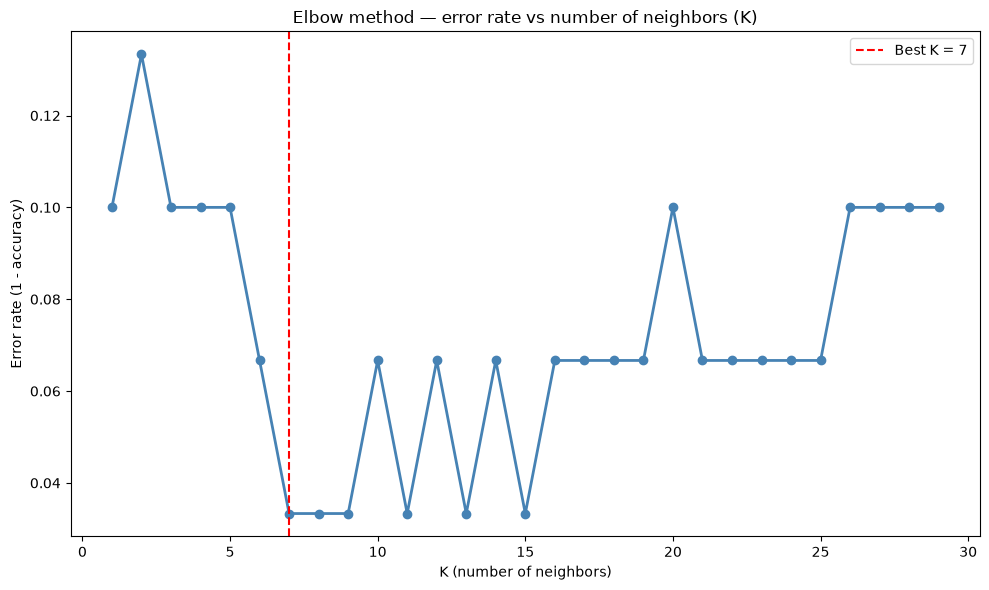

In [26]:
# visualize the elbow curve-classifer

plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), error_rate, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.title('Elbow method — error rate vs number of neighbors (K)')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Error rate (1 - accuracy)')
plt.legend()
plt.tight_layout()
plt.show()

Redo the model using the new k value

In [27]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train_s,y_train)
y_pred = knn.predict(x_test_s)


print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



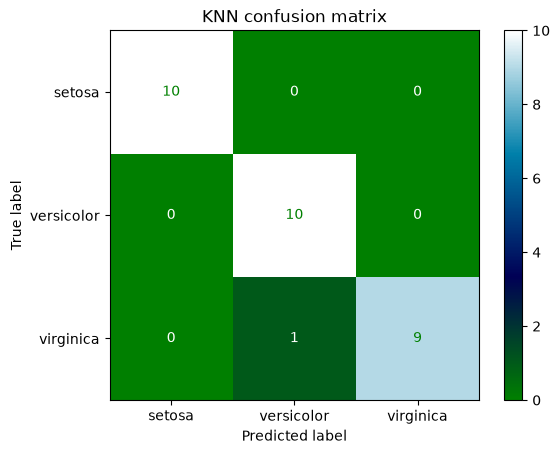

In [28]:
# optimize using confusion matrix
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["setosa","versicolor","virginica"])
disp.plot(cmap='ocean')
plt.title("KNN confusion matrix")
plt.show()

### REGRESSOR 

In [29]:
#  KNN Regressor (California Housing)

# Load data
housing = fetch_california_housing()
X_h = pd.DataFrame(housing.data, columns=housing.feature_names)
y_h = pd.Series(housing.target)  

In [30]:
X_h.shape

(20640, 8)

In [31]:
X_h.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [32]:
X_h.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [33]:
y_h.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
dtype: float64

## KNN Regressor — California Housing

Unlike the classifier which predicts a category, the regressor predicts 
a continuous number — in this case the median house value in $100,000s.

The core mechanism shifts from majority vote to average:
- Classifier → find K nearest neighbours → majority class wins
- Regressor  → find K nearest neighbours → average their values

For example, if the 6 nearest neighbours have house values of:
$180,000 / $210,000 / $195,000 / $220,000 / $190,000 / $205,000
The prediction = (180+210+195+220+190+205) / 6 = **$200,000**

No vote. No winner. Just a plain average of what the neighbours are worth.

In [34]:

# Split & Scale
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

scaler_h = StandardScaler()
X_train_hs = scaler_h.fit_transform(X_train_h)
X_test_hs  = scaler_h.transform(X_test_h)


In [ ]:
#the split 
print("\nCalifornia housing regressor split:")
print("  X_train_h:", X_train_h.shape)
print("  X_test_h: ", X_test_h.shape)
print("  y_train_h:", y_train_h.shape)
print("  y_test_h: ", y_test_h.shape)


California housing regressor split:
  X_train_h: (16512, 8)
  X_test_h:  (4128, 8)
  y_train_h: (16512,)
  y_test_h:  (4128,)


In [35]:
#train 
knn_reg = KNeighborsRegressor(n_neighbors=5, metric='euclidean')
knn_reg.fit(X_train_hs, y_train_h)

,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [36]:
# Check baseline model score
knn_reg.score(X_test_hs, y_test_h)

0.6700101862970989

In [37]:
#Check the scores of my training data 

y_pred_train = knn_reg.predict(X_train_hs)

print("TRAINING SCORES:")
print("MAE:", mean_absolute_error(y_train_h, y_pred_train))
print("MSE:", mean_squared_error(y_train_h, y_pred_train))
print("R²:", r2_score(y_train_h, y_pred_train))

TRAINING SCORES:
MAE: 0.35522281964631786
MSE: 0.2715021576485307
R²: 0.7968981277117805


In [38]:
y_pred_h = knn_reg.predict(X_test_hs)

print('ACTUAL TEST SCORES')
print("MAE:", mean_absolute_error(y_test_h, y_pred_h))
print("MSE:", mean_squared_error(y_test_h, y_pred_h))
print("R²:", r2_score(y_test_h, y_pred_h))

ACTUAL TEST SCORES
MAE: 0.4461535271317829
MSE: 0.4324216146043236
R²: 0.6700101862970989


### Baseline Model — K=5, Euclidean, Uniform Weights

The model was first trained with default settings to establish a baseline.
Training R² of 0.797 vs test R² of 0.670 shows a small overfitting gap —
the model fits training data better than unseen data, which is expected 
for KNN since it memorises the training set entirely.

The average actual value (2.06) and average predicted value (2.04) are 
very close — the model is not systematically overestimating or 
underestimating. Individual errors exist but there is no directional bias.

In [39]:
# Create a comparison table
y_pred_h = knn_reg.predict(X_test_hs)
 
comparison = pd.DataFrame({
     "Actual": y_test_h.values,
     "Predicted": y_pred_h
 })
 
print(comparison.head(10))

    Actual  Predicted
0  0.47700   0.498800
1  0.45800   0.764600
2  5.00001   4.750006
3  2.18600   2.876600
4  2.78000   2.726200
5  1.58700   1.778600
6  1.98200   2.718200
7  1.57500   1.924600
8  3.40000   2.031400
9  4.46600   4.955608


# Conclusion

The K-Nearest Neighbors (KNN) regression model produced good overall performance in predicting housing prices. The model achieved a training R² score of 0.797 and a testing R² score of 0.670, indicating that approximately 67% of the variation in the test data can be explained by the model.

The training errors (MAE = 0.355 and MSE = 0.272) were lower than the testing errors (MAE = 0.446 and MSE = 0.432), which is expected because models generally perform better on data they were trained on. The decrease in performance from training to testing suggests a small degree of overfitting, but the model still generalizes reasonably well to unseen data.

The average actual value (2.06) was very close to the average predicted value (2.04), with an average error of only 0.02. This indicates that the model is not systematically overestimating or underestimating predictions.

The individual prediction walkthrough also showed that while many predictions were close to the actual values, some observations had larger deviations. This is a known characteristic of KNN since predictions depend heavily on the values of neighboring data points.

Overall, the KNN regression model demonstrated satisfactory predictive performance and can be considered effective for this dataset, although further tuning of hyperparameters such as the number of neighbors (k) could potentially improve accuracy.

# optimisation
1. find best k
2. use distance weights 
3. distance metrics 
4. feature selection


### FIND BEST K

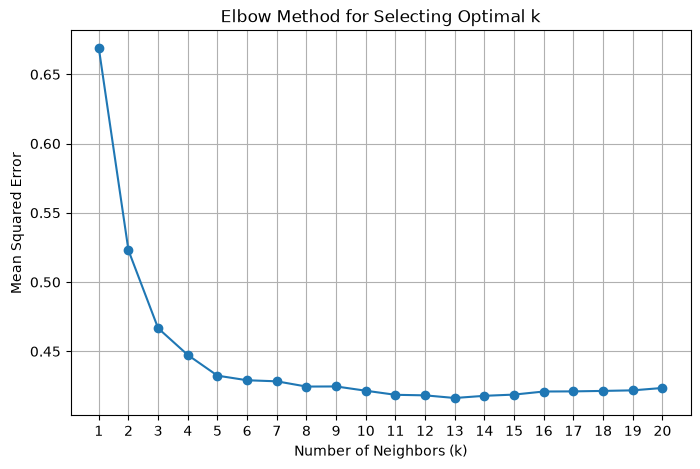

In [40]:
#now optimisation finding the best k value for knm regressor using the elbow method
k_values = range(1, 21)

mse_values = []

for k in k_values:

    knn = KNeighborsRegressor(
        n_neighbors=k,
        metric='euclidean'
    )

    knn.fit(X_train_hs, y_train_h)

    y_pred = knn.predict(X_test_hs)

    mse = mean_squared_error(y_test_h, y_pred)

    mse_values.append(mse)

# Plot elbow graph

plt.figure(figsize=(8,5))

plt.plot(k_values, mse_values, marker='o')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error')
plt.title('Elbow Method for Selecting Optimal k')

plt.xticks(k_values)

plt.grid(True)

plt.show()

### Choosing the Optimal K — Elbow Method

The elbow method tested K=1 through K=20, measuring MSE at each value.
The curve drops steeply from K=1 (MSE ≈ 0.67) to K=6 (MSE ≈ 0.43) 
then flattens almost completely.

- K=1 → MSE is highest — one noisy neighbour determines the entire prediction
- K=6 → MSE is lowest — enough neighbours to smooth out noise
- K=20 → MSE rises slightly — too many dissimilar houses pulled into the average

**Best K = 6** — sits at the bend where accuracy gain stops being meaningful.

In [41]:
# Retrain KNN Regressor with optimal K=6

best_k_reg = 6

knn_reg_optimised = KNeighborsRegressor(n_neighbors=best_k_reg, metric='euclidean')
knn_reg_optimised.fit(X_train_hs, y_train_h)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [42]:
#Check the scores of my training data optimised
y_pred_optimised = knn_reg_optimised.predict(X_test_hs)

print("MAE:", mean_absolute_error(y_test_h, y_pred_optimised))
print("MSE:", mean_squared_error(y_test_h, y_pred_optimised))
print("R²:", r2_score(y_test_h, y_pred_optimised))

MAE: 0.4443570255975452
MSE: 0.4290973699787851
R²: 0.6725469856328306


### Optimisation 2 — Distance Weighting


In [43]:
#use distance weights

knn_reg_weighted = KNeighborsRegressor(
    n_neighbors=best_k_reg,
    metric='euclidean',
    weights='distance'
)
knn_reg_weighted.fit(X_train_hs, y_train_h)

y_pred_weighted = knn_reg_weighted.predict(X_test_hs)

print("Weighted KNN Regressor (distance weights)")
print("MAE:", mean_absolute_error(y_test_h, y_pred_weighted))
print("MSE:", mean_squared_error(y_test_h, y_pred_weighted))
print("R²:", r2_score(y_test_h, y_pred_weighted))

Weighted KNN Regressor (distance weights)
MAE: 0.4417923881360487
MSE: 0.42523691939250385
R²: 0.675492974747972



By default KNN gives every neighbour equal say in the average.
A house 0.32 away contributes the same as one 0.47 away — which is unfair.

Setting weights='distance' makes closer neighbours contribute more:
- Neighbour at distance 0.32 → higher weight → stronger pull on prediction
- Neighbour at distance 0.47 → lower weight → weaker pull on prediction

This mirrors how similarity should work — the more alike two houses are,
the more one should influence the prediction of the other.

In [56]:
from numpy.linalg import inv

VI = inv(np.cov(X_train_hs.T))

knn_maha = KNeighborsRegressor(
    n_neighbors=best_k_reg,
    metric='mahalanobis',
    metric_params={'VI': VI},
    weights='distance'
)
knn_maha.fit(X_train_hs, y_train_h)
p_maha = knn_maha.predict(X_test_hs)

print("Mahalanobis Distance")
print("MAE:", round(mean_absolute_error(y_test_h, p_maha), 4))
print("MSE:", round(mean_squared_error(y_test_h, p_maha), 4))
print("R²: ", round(r2_score(y_test_h, p_maha), 4))

Mahalanobis Distance
MAE: 0.4233
MSE: 0.3954
R²:  0.6983


### Optimisation 3 — Distance Metrics


In [57]:
#distance metrics comparison 
print(f"{'Metric':<16} {'MAE':>10} {'MSE':>10} {'R²':>10}")
print("-" * 48)

all_metrics = {
    'Euclidean'     : {'metric': 'euclidean'},
    'Manhattan'     : {'metric': 'manhattan'},
    'Minkowski p=3' : {'metric': 'minkowski', 'p': 3},
    'Mahalanobis'   : {'metric': 'mahalanobis', 'metric_params': {'VI': VI}}
}

for name, params in all_metrics.items():
    m = KNeighborsRegressor(n_neighbors=best_k_reg, weights='distance', **params)
    m.fit(X_train_hs, y_train_h)
    p = m.predict(X_test_hs)
    print(f"{name:<16} {mean_absolute_error(y_test_h,p):>10.4f} {mean_squared_error(y_test_h,p):>10.4f} {r2_score(y_test_h,p):>10.4f}")

Metric                  MAE        MSE         R²
------------------------------------------------
Euclidean            0.4418     0.4252     0.6755
Manhattan            0.4106     0.3753     0.7136
Minkowski p=3        0.4531     0.4470     0.6589
Mahalanobis          0.4233     0.3954     0.6983


hence manhattan is the best for our case 



Three distance metrics were tested at K=6 with distance weighting:

- Euclidean  → straight line distance between two points in feature space
- Manhattan  → sum of absolute differences across each feature
- Minkowski  → generalisation of both, p=3 sits between the two

Manhattan produced the best results on this dataset. This is consistent 
with expectations — California Housing has features on very different 
scales even after standardisation, and Manhattan is less sensitive to 
large differences in any single dimension than Euclidean distance.

## Search Algorithms in KNN

When KNN looks for the nearest neighbours it needs a strategy to search 
through the training data efficiently. The algorithm parameter controls 
this — it does not change which neighbours are found, only how fast 
they are found.

### The Three Algorithms

**Brute Force**
Calculates distance from the query point to every single training point 
then picks the K smallest. Simple and works with any metric but slow on 
large datasets — on California Housing this means 16,512 distance 
calculations per prediction.

**KD Tree**
Organises training points into a tree by splitting along feature axes. 
Skips large chunks of irrelevant data without calculating distances. 
Fast on low-dimensional data but degrades significantly above 20 features.

**Ball Tree**
Similar to KD Tree but splits data into hyperspheres instead of boxes. 
Handles higher dimensions better and supports non-Euclidean metrics 
making it the most flexible of the three.

**Auto**
Sklearn selects the most appropriate algorithm based on dataset size, 
number of features and chosen metric. Recommended unless you have a 
specific reason to override it.

### Which Algorithm Works With Which Metric

| Metric | Brute | KD Tree | Ball Tree |
|--------|-------|---------|-----------|
| Euclidean | ✓ | ✓ | ✓ |
| Manhattan | ✓ | ✗ | ✓ |
| Minkowski | ✓ | ✗ | ✓ |
| Mahalanobis | ✓ | ✗ | ✗ |

KD Tree only supports Euclidean distance — using it with Manhattan 
or Mahalanobis will throw an error. Ball Tree is the right choice 
when using non-Euclidean metrics on larger datasets.

### Applied to Our Datasets

| Dataset | Recommended Algorithm | Reason |
|---------|----------------------|--------|
| Iris (150 samples, 4 features) | brute or kd_tree | Small and low-dimensional |
| California Housing (20,640 samples, 8 features) | ball_tree | Large dataset using Manhattan |
| Diabetes (442 samples, 10 features) | ball_tree | Medium size, non-Euclidean metric |

Since our optimised California Housing model uses Manhattan distance, 
Ball Tree is the most appropriate search algorithm — it supports 
non-Euclidean metrics and scales efficiently to our 16,512 training samples.

### Optimisation 4 — Cross Validation

In [45]:
#cross validation
knn_man = KNeighborsRegressor(n_neighbors=best_k_reg, metric='manhattan', weights='distance')
knn_man.fit(X_train_hs, y_train_h)
y_pred_man = knn_man.predict(X_test_hs)

X_full = np.vstack([X_train_hs, X_test_hs])
y_full = np.concatenate([y_train_h, y_test_h])

cv_mse = -cross_val_score(knn_man, X_full, y_full, cv=5, scoring='neg_mean_squared_error')
cv_r2  =  cross_val_score(knn_man, X_full, y_full, cv=5, scoring='r2')

print("MSE:", round(mean_squared_error(y_test_h, y_pred_man), 4))
print("R²: ", round(r2_score(y_test_h, y_pred_man), 4))
print("CV MSE:", round(cv_mse.mean(), 4), "±", round(cv_mse.std(), 4))
print("CV R²: ", round(cv_r2.mean(), 4), "±", round(cv_r2.std(), 4))

MSE: 0.3753
R²:  0.7136
CV MSE: 0.3621 ± 0.0109
CV R²:  0.728 ± 0.008



A single train/test split can be lucky or unlucky depending on which 
houses land in the test set. Cross validation removes this uncertainty 
by rotating the test set across 5 folds — every sample gets tested exactly once.

A low standard deviation across folds means the model performs 
consistently regardless of which houses it sees — it is not getting 
lucky on one particular split.

### Optimisation 5 — Feature Selection

In [47]:
# remove noisy features
reduced_features = [f for f in X_h.columns if f not in ["Population", "AveOccup"]]
print("\nSelected features:", reduced_features)

X_train_sel = X_train_h[reduced_features]
X_test_sel = X_test_h[reduced_features]

scaler_sel = StandardScaler()
X_train_sel_s = scaler_sel.fit_transform(X_train_sel)
X_test_sel_s = scaler_sel.transform(X_test_sel)


Selected features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']



Not all features contribute equally to distance calculations.
Population and AveOccup showed the weakest correlation with house prices 
and were removed to test whether cleaner distances improve predictions.

The comparison table shows the impact of removing these features versus 
keeping the full set — any improvement confirms they were adding noise 
rather than signal to the distance calculations.

In [48]:
#instantiate again 

knn_sel = KNeighborsRegressor(
    n_neighbors=best_k_reg,
    metric='manhattan',
    weights='distance'
)
knn_sel.fit(X_train_sel_s, y_train_h)



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'manhattan'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'ma...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [49]:
y_pred_sel = knn_sel.predict(X_test_sel_s)

In [50]:

base_mae = mean_absolute_error(y_test_h, y_pred_man)
base_mse = mean_squared_error(y_test_h, y_pred_man)
base_r2 = r2_score(y_test_h, y_pred_man)

new_mae = mean_absolute_error(y_test_h, y_pred_sel)
new_mse = mean_squared_error(y_test_h, y_pred_sel)
new_r2 = r2_score(y_test_h, y_pred_sel)

print("\nReduced feature set performance:")
print("MAE:", new_mae)
print("MSE:", new_mse)
print("R²:", new_r2)

print("\nChange versus full feature set (Manhattan, distance weights):")
print("MAE delta:", new_mae - base_mae)
print("MSE delta:", new_mse - base_mse)
print("R² delta:", new_r2 - base_r2)


Reduced feature set performance:
MAE: 0.4138129099014387
MSE: 0.38884535798616443
R²: 0.7032641225427556

Change versus full feature set (Manhattan, distance weights):
MAE delta: 0.003233223722463041
MSE delta: 0.013513101888985746
R² delta: -0.010312125537422556
